# The objective if to design and built a VGG-16 Model for CIFAR-10 Classification using PyTorch by Loading CIFAR-10 dataset and Modify VGG-16 for 10 classes. Train and evaluate with accuracy, precision, recall, and confusion matrix.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Define data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images for VGG-16
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

# Load CIFAR-10 dataset
batch_size = 32
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Class labels
class_names = train_dataset.classes
print("Classes:", class_names)

100%|███████████████████████████████████████████████████████████████| 170498071/170498071 [00:20<00:00, 8394120.86it/s]


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Load Pretrained VGG-16 Model

In [4]:
model = models.vgg16(pretrained=True)

# Modify the classifier for 10 classes
model.classifier[6] = nn.Linear(4096, 10)  # Change output to 10 classes
model = model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Print model architecture
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# Train the Model

Epoch 1/10, Loss: 0.2677, Accuracy: 0.9104


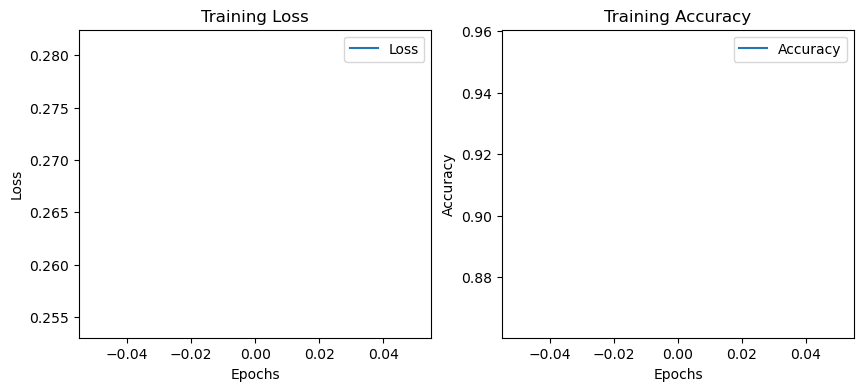

KeyboardInterrupt: 

In [6]:
# Training function with visualization
def train_model(model, train_loader, criterion, optimizer, num_epochs=1):
    train_losses, train_accuracies = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

        # Visualize Training Progress
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label="Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Training Loss")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label="Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title("Training Accuracy")
        plt.legend()

        plt.show()

    print("Training Complete!")
    return model

# Train the model
model = train_model(model, train_loader, criterion, optimizer, num_epochs=10)

# Save the trained model
torch.save(model.state_dict(), "vgg16_cifar10.pth")
print("Model Saved!")

# Evaluate the Model

In [7]:
# Evaluate the model
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    return all_labels, all_preds

# Run evaluation
y_true, y_pred = evaluate_model(model, test_loader)

Test Accuracy: 90.32%


# Visualize Model Predictions

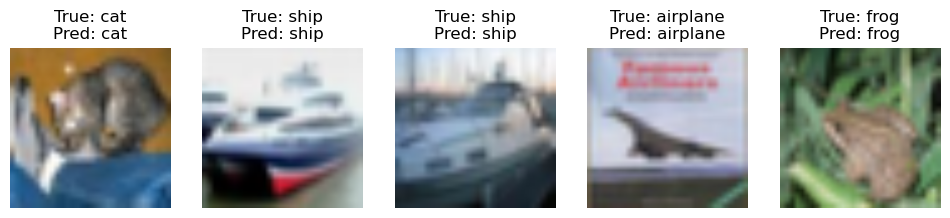

In [8]:
# Display test results with images
def visualize_predictions(test_loader, model, class_names, num_images=5):
    model.eval()
    images, labels = next(iter(test_loader))
    images, labels = images[:num_images], labels[:num_images]

    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)

    plt.figure(figsize=(12, 5))
    for i in range(num_images):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5  # Undo normalization

        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
        plt.axis("off")

    plt.show()

# Show predictions
visualize_predictions(test_loader, model, class_names)

In [9]:
# Display How Weights Changed

# Display Feature Maps

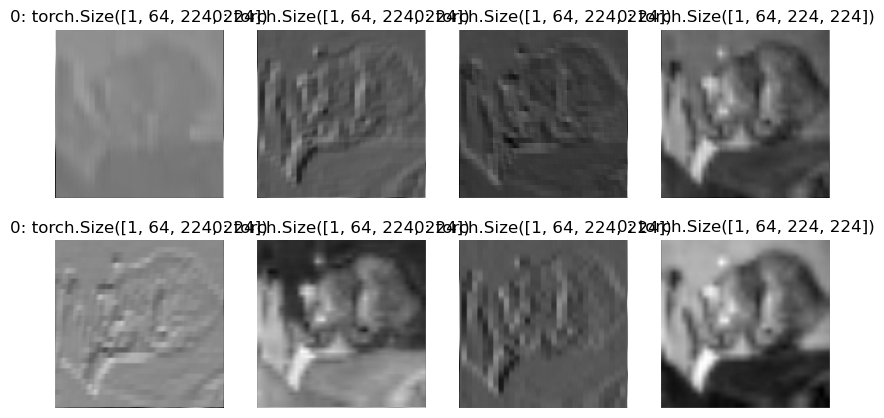

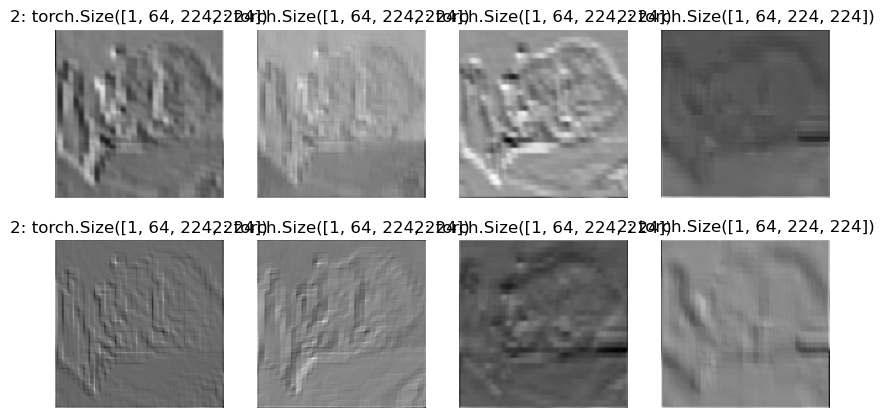

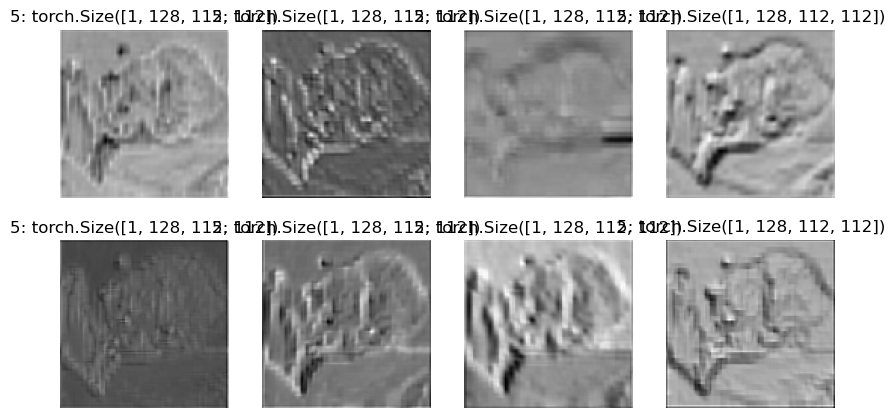

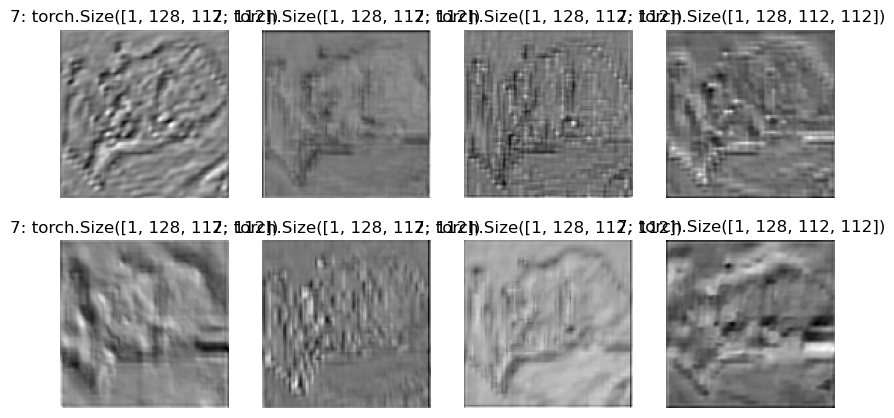

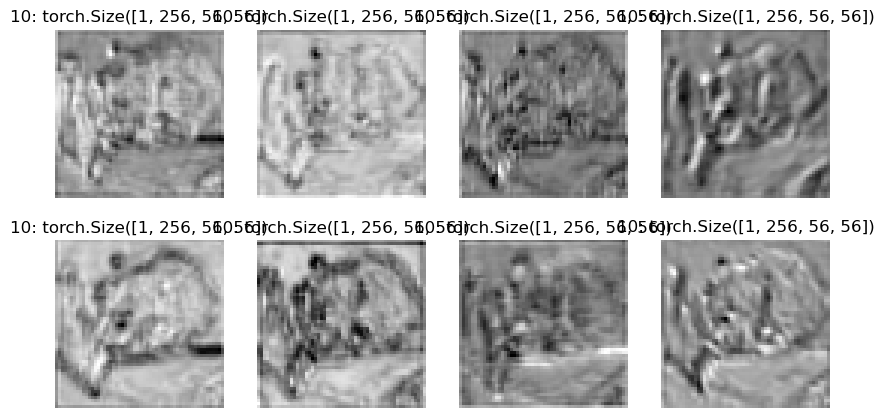

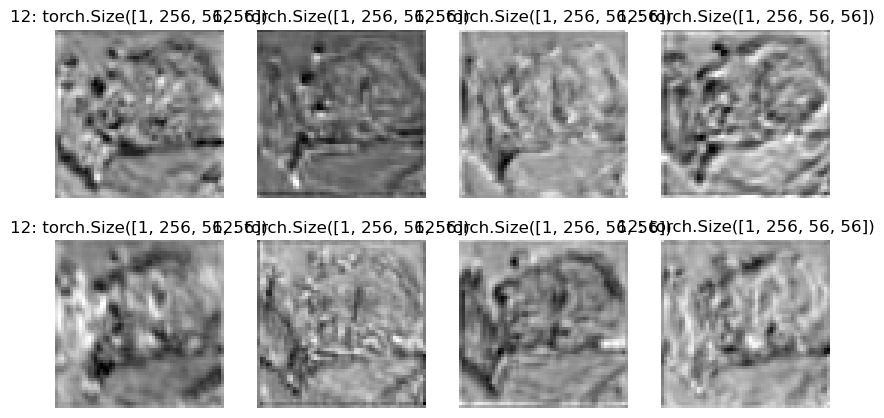

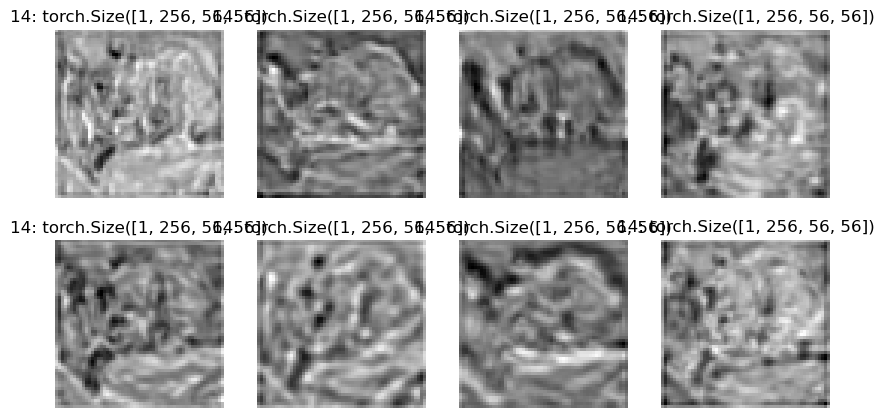

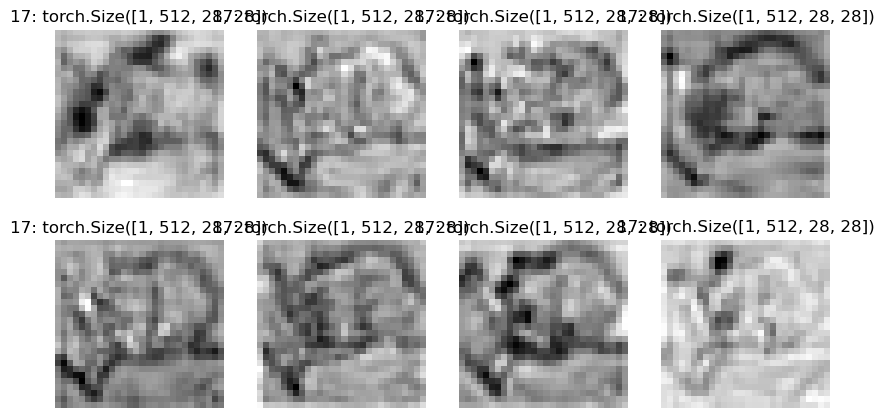

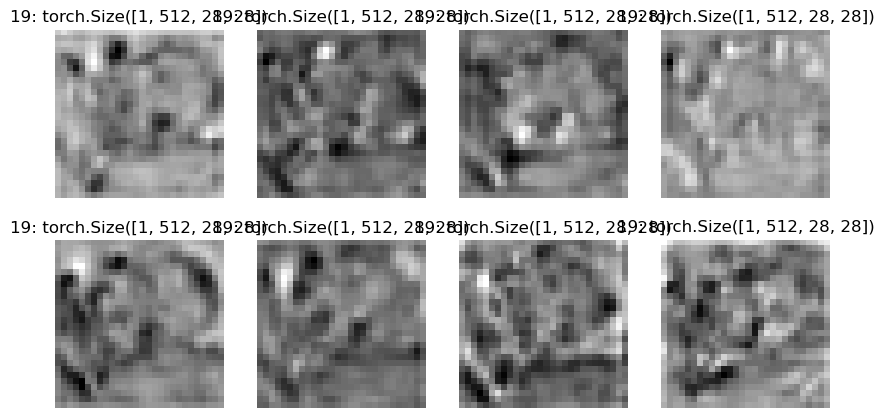

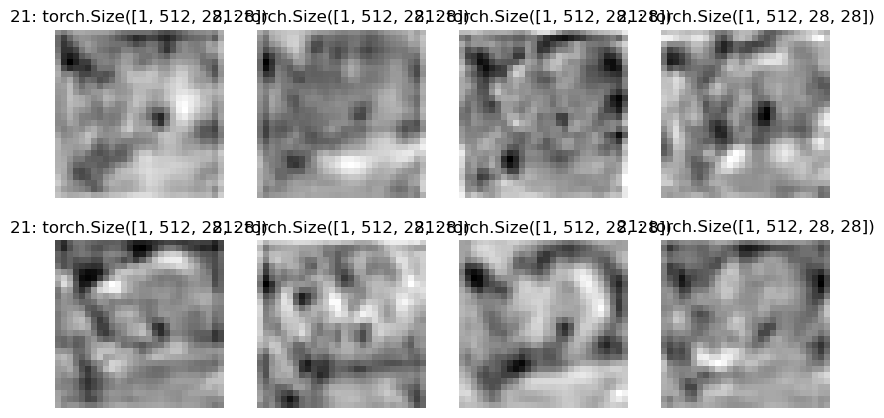

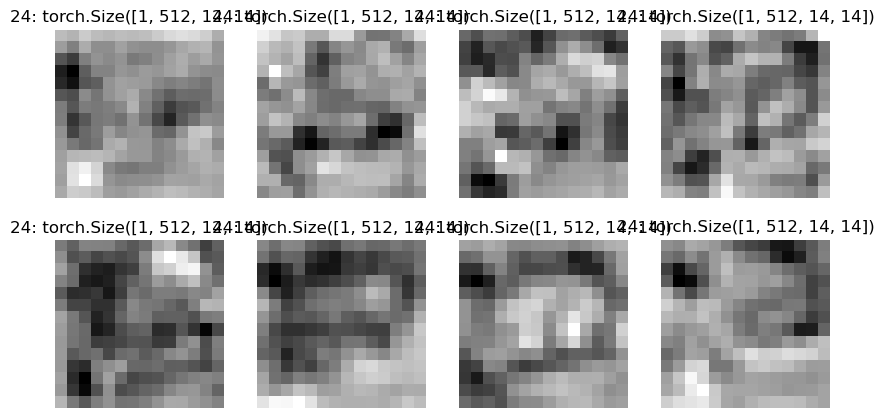

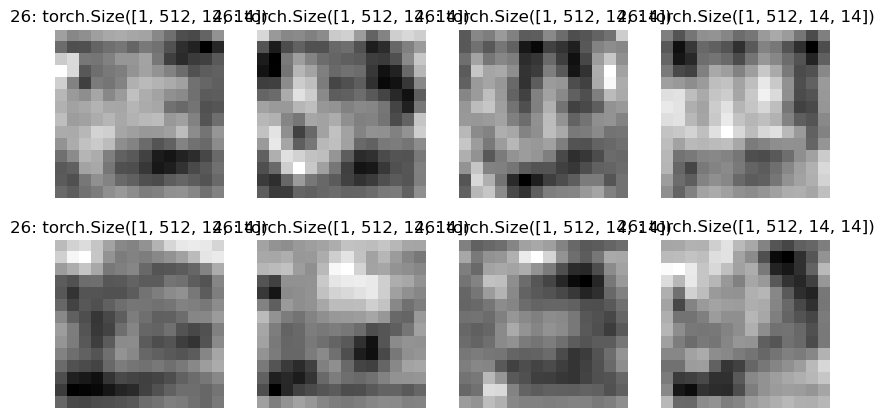

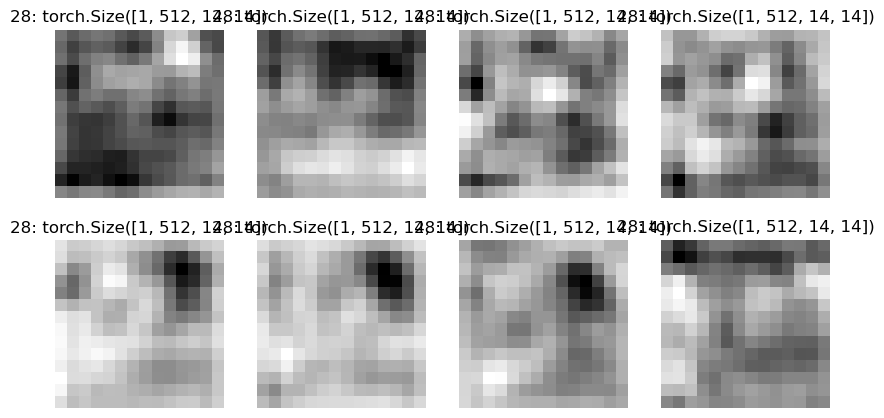

In [11]:
# Visualize feature maps
def show_feature_maps(model, image):
    image = image.unsqueeze(0).to(device)

    for name, layer in model.features._modules.items():
        image = layer(image)

        if isinstance(layer, nn.Conv2d):
            plt.figure(figsize=(10, 5))
            for i in range(min(8, image.shape[1])):  # Show only first 8 feature maps
                plt.subplot(2, 4, i+1)
                plt.imshow(image[0, i].cpu().detach().numpy(), cmap='gray')
                plt.title(f"{name}: {image.shape}")
                plt.axis("off")
            plt.show()

# Show feature maps for one test image
sample_image, _ = test_dataset[0]
show_feature_maps(model, sample_image)